# Simulating on a Par 3 - hole 9 MM

In [14]:
import pandas as pd
import numpy as np
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [15]:
lpga_clubs = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Trackman Fake Data/simulated_lpga_shot_data.csv")
hole_9 = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")

### Selecting Teebox

In [16]:
# to get the centre of shapes
def get_centroid(row):
    shape = wkt.loads(row["WKT"])
    return shape.centroid.coords[0] # returns the x,y coords

# finding furthest teebox
teeboxes = hole_9[hole_9["lie"].str.contains("tee", case = False)]
green = hole_9[hole_9["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green["WKT"])
green_centre = get_centroid(green)
# getting different teeboxes centre
teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column

# distances to green
teeboxes["dist_to_green"] = teeboxes["centroid"].apply(
    # np.array(pt) - np.array(green_centre) -> subtracts the two 2d points, and linalg compute the euclidean distance
    lambda pt: np.linalg.norm(np.array(pt) - np.array(green_centre))
)

longest_teebox = teeboxes.loc[teeboxes["dist_to_green"].idxmax()]
tee_point = longest_teebox["centroid"]


# --- from simulating putting, to define random hole location
def sample_point_on_green(green_shape):
    # get the bounds of the green shape
    minx, miny, maxx, maxy = green_shape.bounds

    while True:
        # randomly generate random coordinate
        x_ball = np.random.uniform(minx, maxx)
        y_ball = np.random.uniform(miny, maxy)
        # check whether point is on green
        if green_shape.contains(Point(x_ball, y_ball)):
            return (x_ball, y_ball)
        
hole = sample_point_on_green(green_shape)

hole = (5, 174)

/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_72860/3202513976.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_72860/3202513976.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


### Printing Pin Position and Tee Box

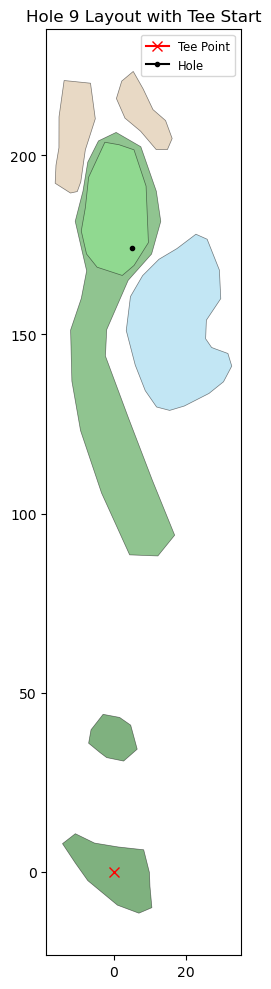

In [17]:
# colors by lie type
lie_colors = {
    "bunker": "tan",
    "fairway": "forestgreen",
    "green": "lightgreen",
    "OB": "lightcoral",
    "rough": "mediumseagreen",
    "tee": "darkgreen",
    "water_hazard": "skyblue"
}

fig, ax = plt.subplots(figsize=(10, 10))

# fill each shape with the appropriate colour
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)

# mark tee and hole
ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=7, label="Tee Point")
ax.plot(hole[0], hole[1], marker='o', color='black', markersize=3, label="Hole")

ax.set_aspect("equal")
ax.set_title("Hole 9 Layout with Tee Start")
ax.legend(loc='upper right', fontsize="small")
plt.tight_layout()
plt.show()


## Simulating Shots
Rotating and translating LPGA shots

### Rotation Matrices
If have a coordinate with form relative to the aimpoint:
$$(x,y)$$
To rotate it $\theta$ degrees anticlockwise (i.e. left), you multiply with:
$$\text{Rot}_{\theta} = \begin{bmatrix} \cos(\theta) &- \sin(\theta)\\
\sin(\theta) & \cos(\theta)\end{bmatrix}$$

In [18]:
def rotation_translator(x_side, y_carry, angle, starting_point, target):

    # base angle from starting_point to target
    line_to_target = np.array(target) - np.array(starting_point)
    base_angle = np.arctan2(line_to_target[1], line_to_target[0])

    # aiming offset
    theta = -np.radians(angle) + base_angle
    # rotation matrix
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

    # Rotate shot vector
    original_vec = np.array([x_side, -y_carry])
    rotated_vec = rot_matrix @ original_vec

    # rotating the *rotated vector* into the global frame using base_angle
    global_rot = np.array([
        [np.cos(base_angle), -np.sin(base_angle)],
        [np.sin(base_angle),  np.cos(base_angle)]
    ])
    final_vec = global_rot @ rotated_vec

    # Add tee location
    return tuple(final_vec + np.array(starting_point))

## Offset Angle in Yards -> SOHCAHTOA FOR INTERPRETABILITY
Want to aim at a point:
- distance d (straight line)
- x lateral offset

So via sohcahtoa

$$\theta = \arctan(\frac{x}{d})$$

In [19]:
def yard_offset_to_angle(yards_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.arctan(yards_offset / dis_target)
    return np.degrees(angle_rad)

def angle_offset_to_yard(angle_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.radians(angle_offset)
    offset = np.tan(angle_rad) * dis_target
    return offset

## Interactive Plot to Visualise Different aimpoints

In [20]:
from ipywidgets import interact, Dropdown, IntSlider

# base distance (to target)
total_distance = np.linalg.norm(np.array(hole) - np.array(tee_point))

# Just for the Drop Down menu
club_order = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]
sorted_clubs = [club for club in club_order if club in lpga_clubs["Club"].unique()]

# Interactive widget with dropdown for irons
@interact(
    club=Dropdown(options=sorted_clubs, value="5 Iron", description="Club:"),
    aim_yards=IntSlider(min=-20, max=20, step=1, value=0, description="Aim (yds):")
)

def plot_rotated_shots(club, aim_yards):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Filter club data
    club_df = lpga_clubs[lpga_clubs["Club"] == club].copy()

    # Convert aim offset in yards to angle in degrees
    angle_rad = np.arctan(aim_yards / total_distance)
    angle_deg = np.degrees(angle_rad)

    # Draw hole
    for _, row in hole_9.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.4)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.4)

    # Plot rotated shots
    for _, row in club_df.iterrows():
        x, y = rotation_translator(row["Side"], row["Carry"], angle_deg, tee_point, hole)
        ax.plot(x, y, marker='.', color='blue', alpha=0.6)

    # Tee & hole
    ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=8, label='Tee')
    ax.plot(hole[0], hole[1], marker='o', color='black', markersize=5, label='Hole')

    # --- Plot Aim Line showing the rotated centerline of shot dispersion ---
    aim_direction = np.array(hole) - np.array(tee_point)
    aim_direction_unit = aim_direction / np.linalg.norm(aim_direction)

    # Rotation matrix to rotate the aim line by the aiming angle (clockwise = positive)
    theta = -angle_rad  # negative so positive input rotates clockwise
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated_aim_direction = rot_matrix @ aim_direction_unit

    # Extend from tee point outward by total_distance
    aim_endpoint = np.array(tee_point) + rotated_aim_direction * total_distance

    # Plot the rotated aim line
    ax.plot(
        [tee_point[0], aim_endpoint[0]],
        [tee_point[1], aim_endpoint[1]],
        linestyle="--",
        color="red",
        label="Aim Point"
    )
    
        # Grid overlay every 5 yards
    ax.set_xticks(np.arange(-40, 40, 10), minor=False)
    ax.set_yticks(np.arange(-50, 251, 10), minor=False)

    ax.grid(which='major', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
    ax.set_title(f"{club} | Aim {aim_yards} yd, {round(angle_deg, 2)}°")
    ax.set_aspect("equal")
    ax.legend()
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Club:', index=5, options=('Driver', '3-wood', '5-wood', 'Hybrid', …

# Simulating, the mathematical way ;)
## Fit Bivariate Gaussian to LPGA Shot Data
Define:
- $X$ -> Side (yards left/right)
- $Y$ -> Carry (forward)

From LPGA shots with a given $\mathcal{c}$:
Compute, gaussian distribution:
$$\mu_{\mathcal{c}} = \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \Sigma_{\mathcal{c}} = \begin{bmatrix} \sigma^2_{X} & \rho\sigma_X\sigma_Y \\
\rho\sigma_X\sigma_Y & \sigma^2_{Y}\end{bmatrix}$$

## Sampling Shots from Gaussian
Simulate $N$ shots
$$\vec{s} \sim \mathcal{N}(\mu_\mathcal c, \Sigma_ \mathcal c)$$

## Rotate and Translate to Hole setting

Let:

* $\vec{v} = \text{unit vector from tee to pin}$
* $\theta = \arctan(\text{aim}_\text{offset} / \text{distance to pin})$

Then:

* Want to rotate each shot $\vec{s}_i$ by angle $\theta$ (clockwise = +)
* Translate from tee location:

$$
\vec{p}_i = \text{Tee} + R(\theta) \cdot \vec{s}_i
$$

## Evaluate Strokes-to-Hole for Each Landing Point

Define function:

$$
\text{ExpectedStrokes}(\vec{p}_i) =
\begin{cases}
\text{GPR-putting} & \text{if } \vec{p}_i \in \text{green} \\
\text{Broadie interpolation} & \text{if } \vec{p}_i \in \text{fairway, rough, bunker} \\
\text{Drop + Broadie} & \text{if } \vec{p}_i \in \text{water}
\end{cases}
$$

## Summarise Results

From values $\{ \text{ES}_i \}_{i=1}^N$, compute:

* $\mathbb{E}[\text{Strokes}] = \frac{1}{N} \sum_i \text{ES}_i$
* $\text{95\% CI} = \text{quantile range of } \{ \text{ES}_i \}$



# Bivariate LPGA distribution
Computing and Plotting for Visual Purpose

## Simulating Shots

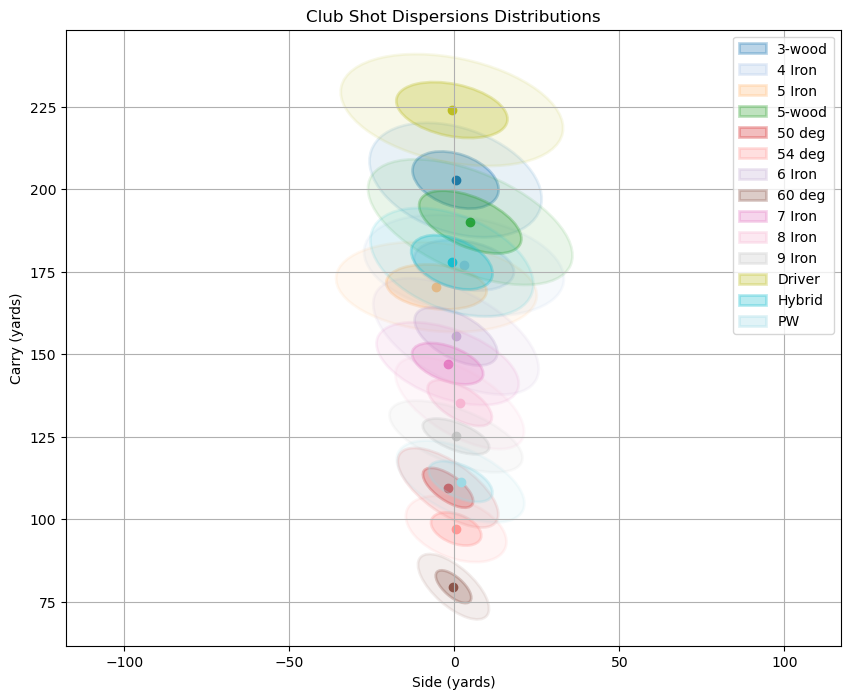

In [21]:
from matplotlib.patches import Ellipse

# side = x, carry = y
club_distributions = {}

for club, group in lpga_clubs.groupby("Club"):
    mean = group[["Side", "Carry"]].mean().to_numpy() 
    cov = np.cov(group[["Side", "Carry"]].T)         

    club_distributions[club] = {
        "mean": mean,
        "cov": cov
    }

def get_club_distribution(club):
    return club_distributions[club]["mean"], club_distributions[club]["cov"]

def plot_all_club_distributions(club_distributions):
    fig, ax = plt.subplots(figsize=(10, 8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(club_distributions)))

    for (club, stats), color in zip(club_distributions.items(), colours):
        mu, cov = stats["mean"], stats["cov"]

        # align axes along eigen vectors
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)

        ellipse_1 = Ellipse(xy=mu, width=width, height=height, angle=angle,
                          edgecolor=color, fc=color, lw=2, label=club, alpha = .3)
        ellipse_2 = Ellipse(xy=mu, width=2*width, height=2*height, angle=angle,
                          edgecolor=color, fc=color, lw=2, alpha = .1)
        ax.add_patch(ellipse_1)
        ax.add_patch(ellipse_2)
        ax.scatter(*mu, color=color, marker='o')

    ax.set_title("Club Shot Dispersions Distributions")
    ax.set_xlabel("Side (yards)")
    ax.set_ylabel("Carry (yards)")
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

# Call it
plot_all_club_distributions(club_distributions)


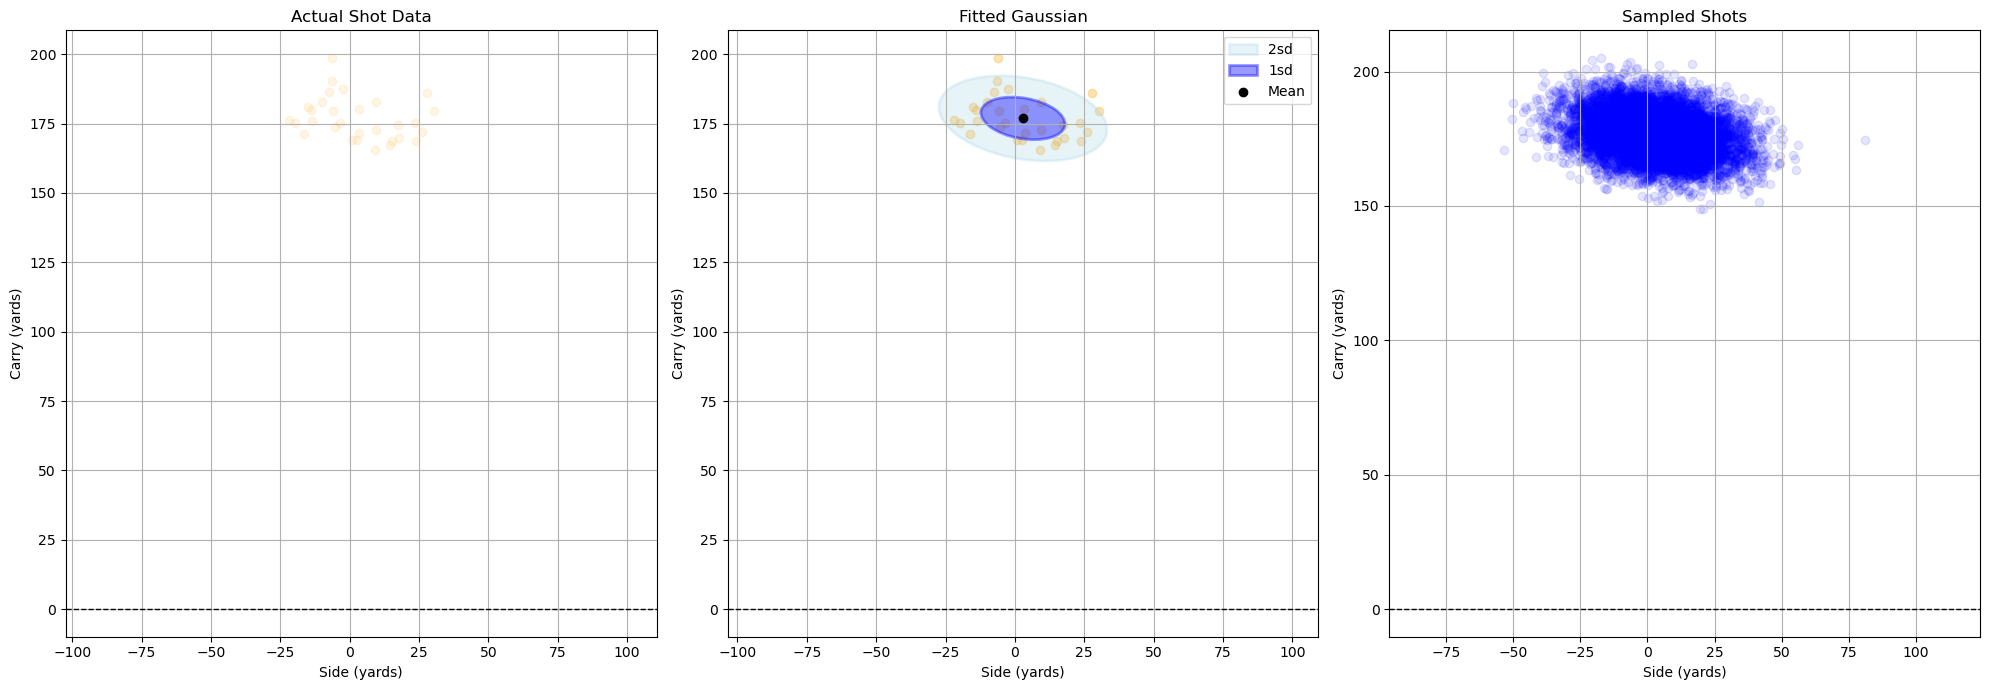

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Select club
club = "4 Iron"
club_data = lpga_clubs[lpga_clubs["Club"] == club][["Side", "Carry"]].to_numpy()

# Get distribution
mu, cov = get_club_distribution(club)

# Eigendecomposition for ellipse
vals, vecs = np.linalg.eigh(cov)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

# Ellipse sizes
width_1sd, height_1sd = 2 * np.sqrt(vals)
width_2sd, height_2sd = 2 * width_1sd, 2 * height_1sd

# Generate samples
samples = np.random.multivariate_normal(mu, cov, size=10000)

# Define plot limits anchored at y = 0, for scale
buffer = 10
x_min = min(np.min(club_data[:, 0]), mu[0] - width_2sd) - buffer
x_max = max(np.max(club_data[:, 0]), mu[0] + width_2sd) + buffer
y_max = max(np.max(club_data[:, 1]), mu[1] + height_2sd) + buffer

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
titles = ["Actual Shot Data", "Fitted Gaussian", "Sampled Shots"]
datasets = [club_data, club_data, samples]
colors = ['orange', 'orange', 'blue']

for ax, title, data, color in zip(axes, titles, datasets, colors):
    ax.axhline(0, color='black', linestyle='--', lw=1)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.set_title(title)
    ax.set_xlabel("Side (yards)")
    ax.set_ylabel("Carry (yards)")
    ax.axis('equal')
    ax.grid(True)

    if title == "Fitted Gaussian":
        ax.scatter(data[:, 0], data[:, 1], alpha=0.3, color=color)
        e1 = Ellipse(xy=mu, width=width_1sd, height=height_1sd, angle=angle,
                     edgecolor='b', fc = "b", lw=2, label='1sd', alpha = .4)
        e2 = Ellipse(xy=mu, width=width_2sd, height=height_2sd, angle=angle,
                     edgecolor='lightblue', fc='lightblue', lw=2, label='2sd', alpha = .3)
        ax.add_patch(e2)
        ax.add_patch(e1)
        ax.scatter(*mu, color="black", label='Mean', zorder=5)
        ax.legend()
    else:
        ax.scatter(data[:, 0], data[:, 1], alpha=0.1, color=color)

plt.tight_layout()
plt.show()



### Shot Evaluation:

For each simulated shot landing point $(x, y)$:

####  If the point is on the green:

* GPR and Modifier Used to Evaluate

#### If point in fairway / rough / bunker:

* Use interpolation from Broadie’s expected strokes tables
* * for now

#### If it lands in water:

* Trace the line from tee to the ball
* Find first intersection with the water polygon
* Compute drop point there and re-evaluate expected strokes from drop point

# Defining Polygons for Simulation / Id of Ball Location

In [23]:
from shapely.geometry import Point

# parsing all shapes
hole_9["shape"] = hole_9["WKT"].apply(wkt.loads)

# Other lies
def get_polygons(df, match):
    return df[df["lie"].str.contains(match, case=False)]["shape"].tolist()

fairway_polygons = get_polygons(hole_9, "fairway")
rough_polygons = get_polygons(hole_9, "rough")
bunker_polygons = get_polygons(hole_9, "bunker")
water_polygons = get_polygons(hole_9, "water")
green_polygon = green_shape 

def get_lie_category(point):
    pt = Point(point)

    if green_polygon.contains(pt):
        return "green"
    if any(poly.contains(pt) for poly in fairway_polygons):
        return "fairway"
    if any(poly.contains(pt) for poly in bunker_polygons):
        return "bunker"
    if any(poly.contains(pt) for poly in rough_polygons):
        return "rough"
    if any(poly.contains(pt) for poly in water_polygons):
        return "water"
    return "unknown"

# Modular functions to compute expectation from different lies + simulation

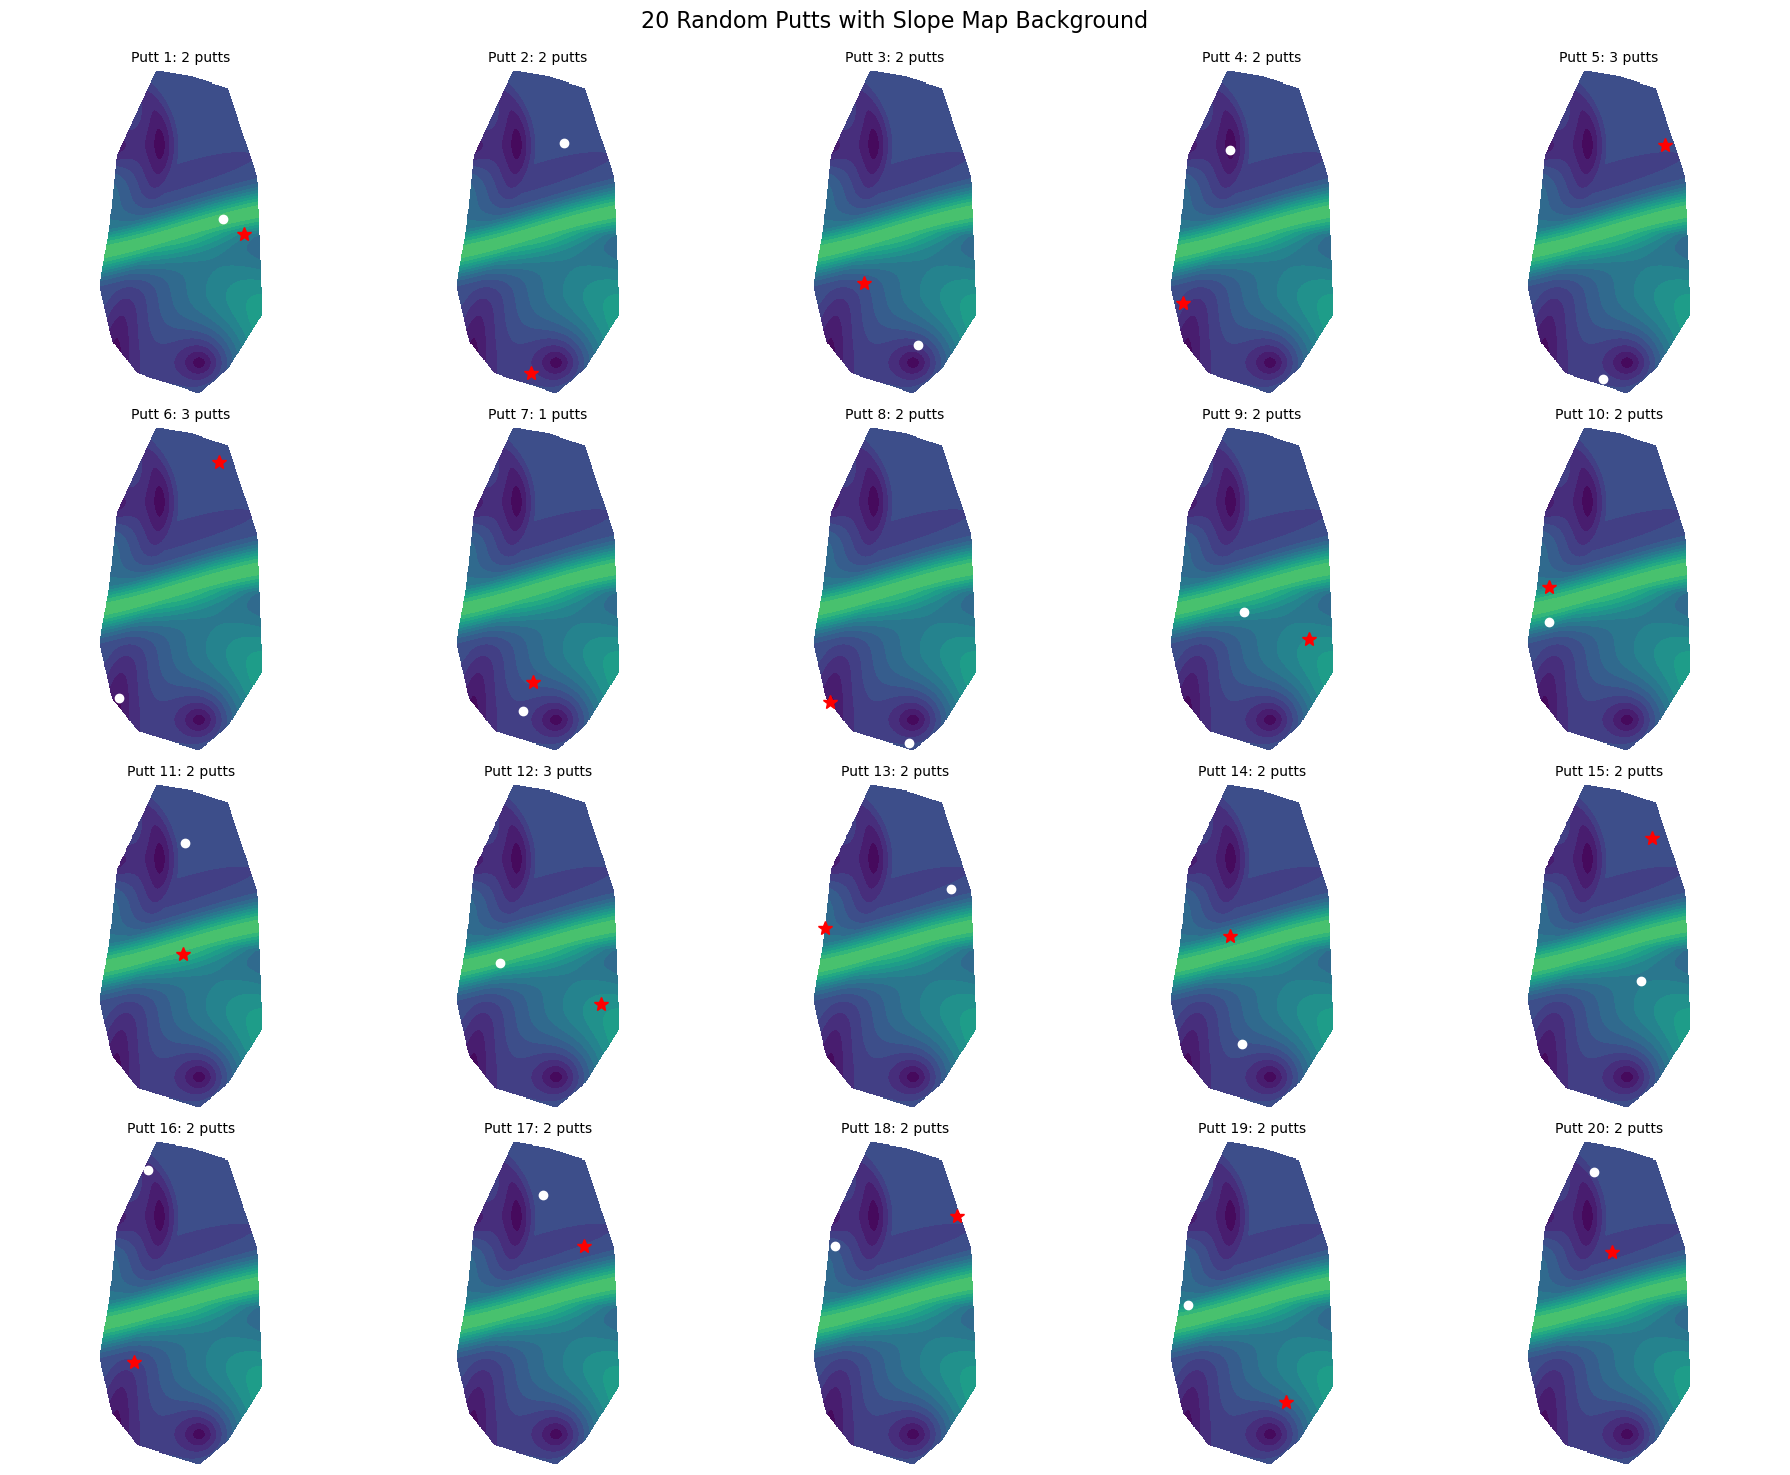

/Users/federicadomecq/Documents/golfModeL47-1/PART 2/Green simulation/expectedputts.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


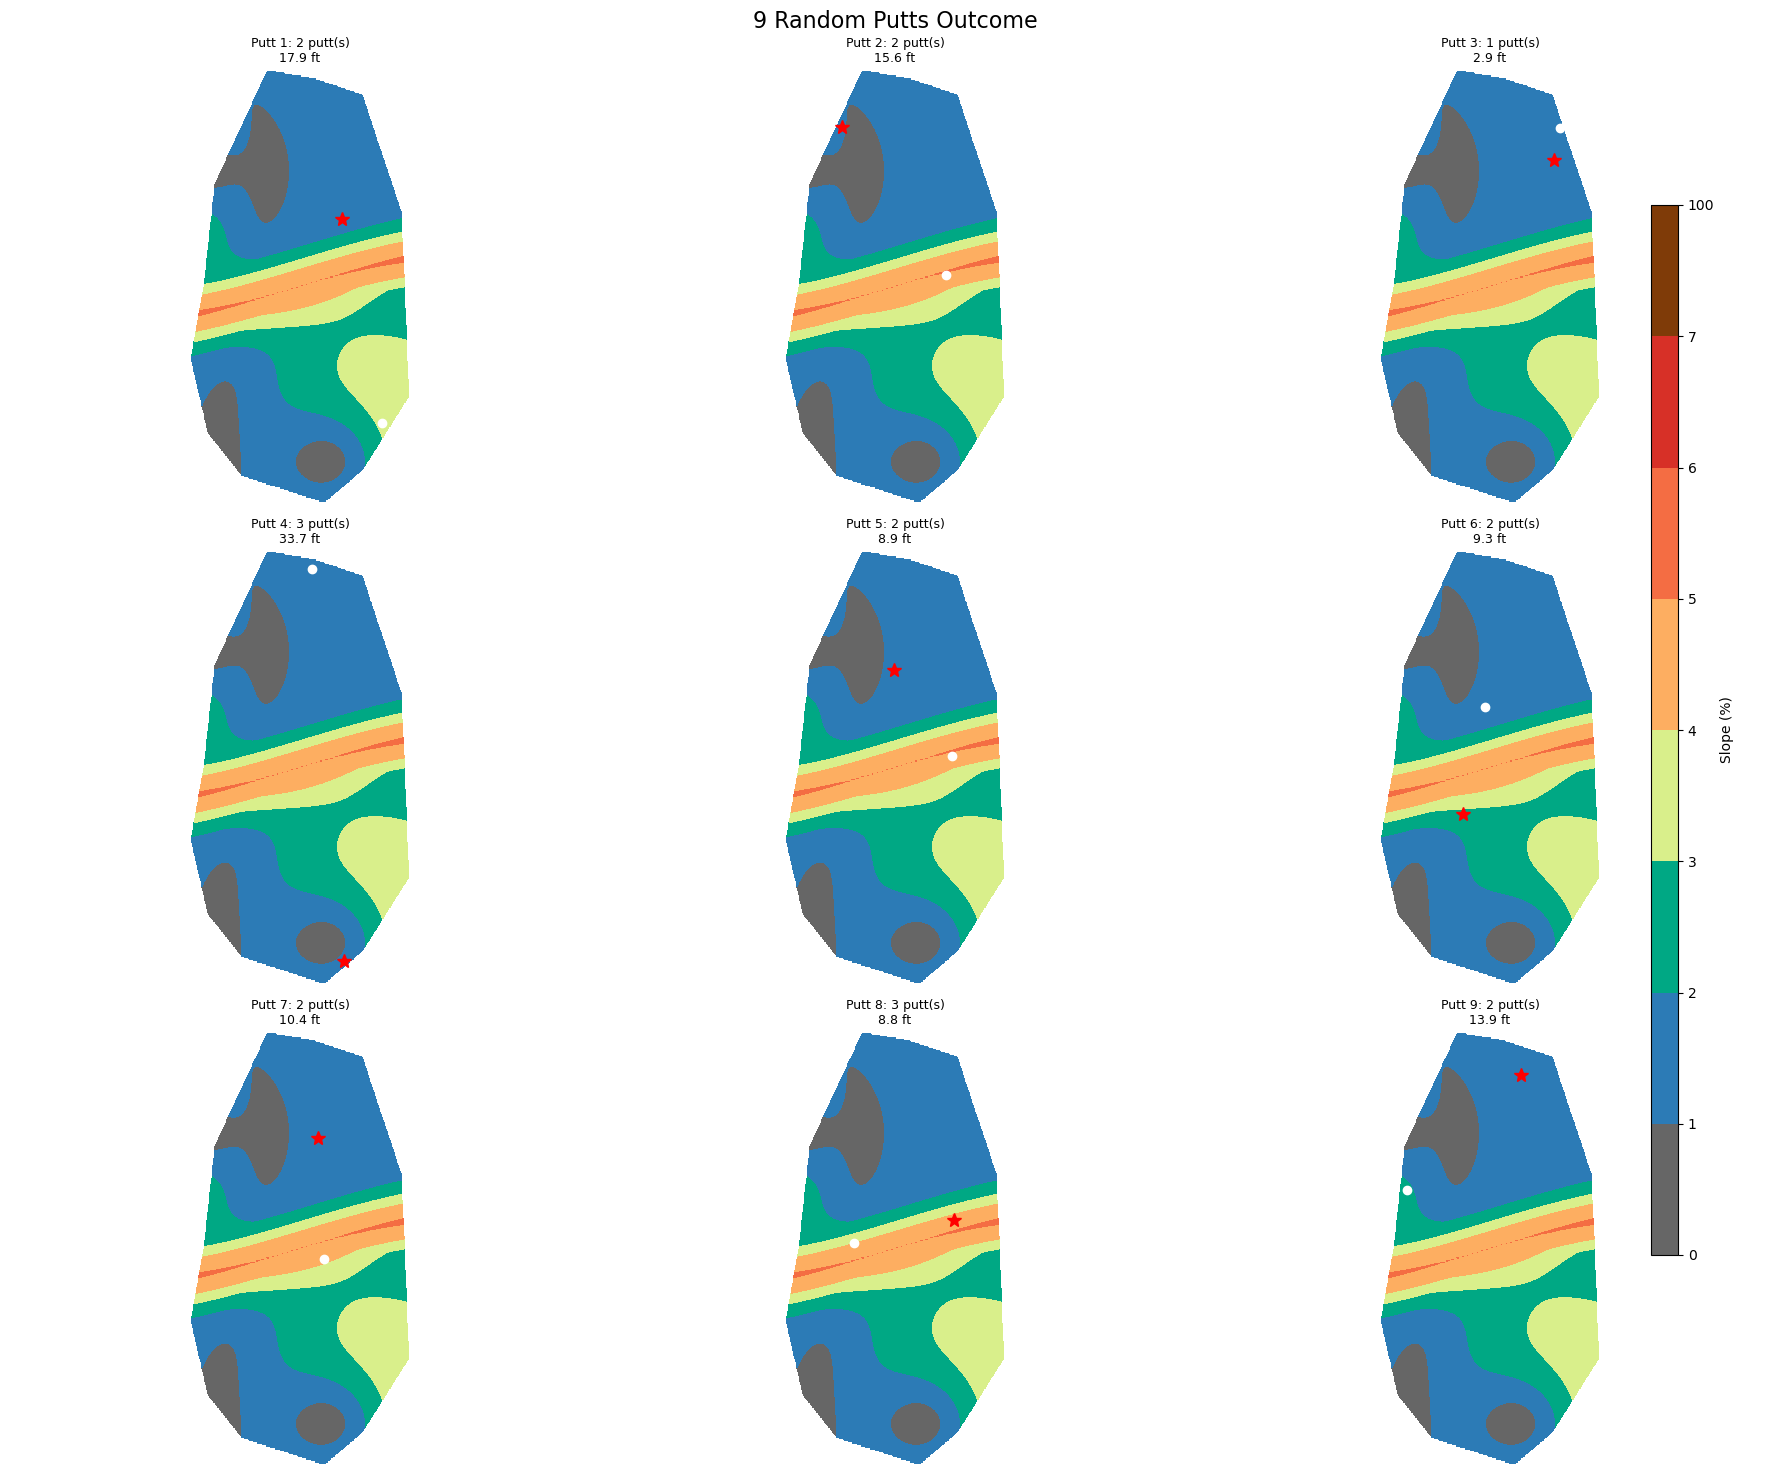

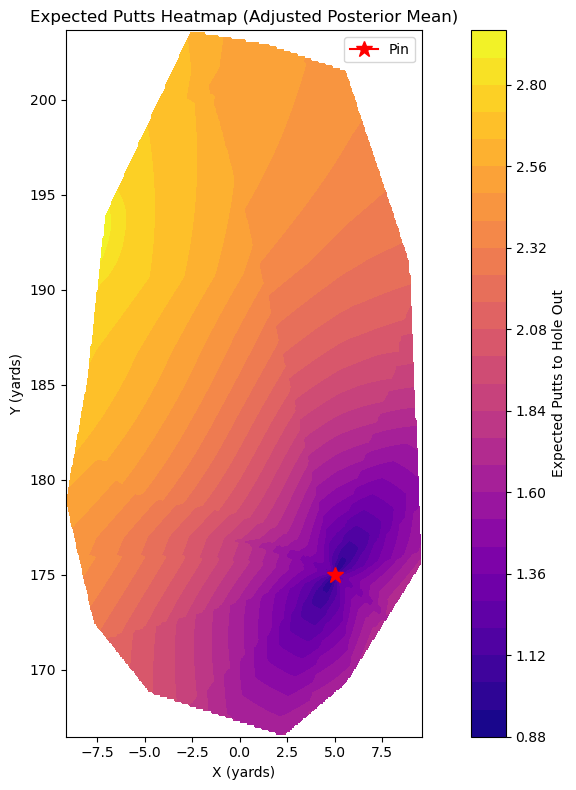

/Users/federicadomecq/Documents/golfModeL47-1/PART 2/Green simulation/expectedputts.py:532: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


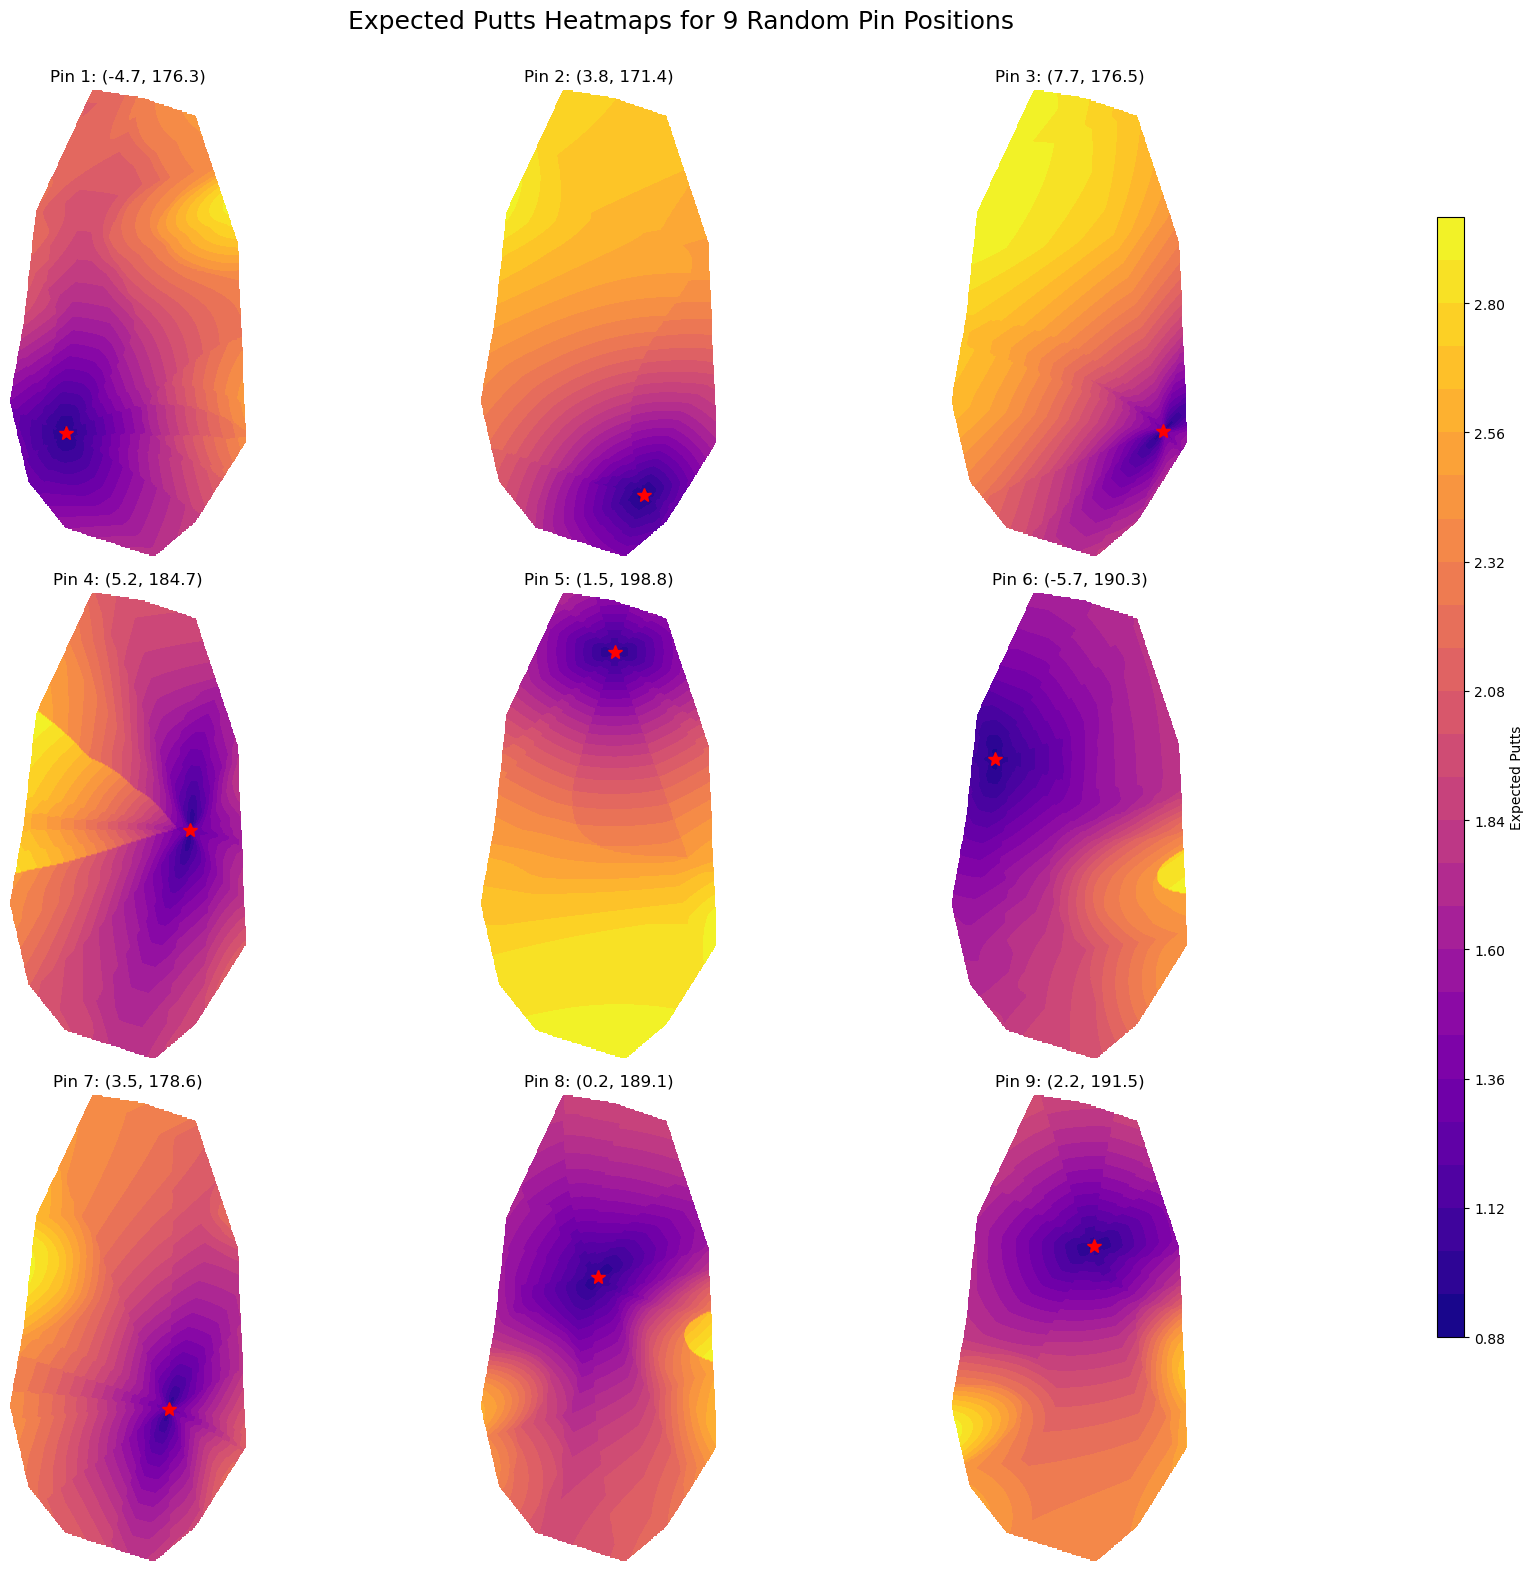

In [24]:
from expectedputts import raw_gpr_pred, tier_multiplier, side_slope_multiplier, uphill_downhill_multiplier
from scipy.interpolate import interp1d
from shapely.geometry import LineString

broadie_data = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_by_lie_yards_broadie.csv")

# interpolators per lie
broadie_interpolators = {}

# Rename for convenience
broadie_data = broadie_data.rename(columns={"Distance (yards)": "distance"})

# Pivot to Long
broadie_long = broadie_data.melt(id_vars="distance", var_name="lie", value_name="strokes")

# Make lie lowercase
broadie_long["lie"] = broadie_long["lie"].str.lower()


for lie, group in broadie_long.groupby("lie"):
    # Sort by distance to ensure monotonic x
    group = group.sort_values("distance")
    f = interp1d(
        group["distance"], group["strokes"],
        kind="linear", fill_value="extrapolate"
    )
    broadie_interpolators[lie.lower()] = f

def interpolate_broadie(lie, distance):
    lie = lie.lower()
    if lie not in broadie_interpolators:
        raise ValueError(f"No interpolator found for lie: {lie}")
    return broadie_interpolators[lie](distance)

# Green -> GPR and Slope Modifier
def evaluate_on_green(point, target):
    mu, sigma = raw_gpr_pred(point, target)

    # Get multipliers
    tier_mult = tier_multiplier(point, target)
    side_mult = side_slope_multiplier(point, target)
    hill_mult = uphill_downhill_multiplier(point, target)

    # Combine and adjust
    total_mean_mult = tier_mult * side_mult * hill_mult
    mu_adj = mu * total_mean_mult

    total_std_mult = 0.85 * total_mean_mult + 0.15
    sigma_adj = sigma * total_std_mult

    return mu_adj



# Any location but green -> INTERPOLATE FROM BROADIE DATA
def evaluate_broadie(point, target, lie):
    dist = np.linalg.norm(np.array(point) - np.array(target))
    return interpolate_broadie(lie, dist)

# Finding water drop location:
def get_water_intersection(starting_point, ball_in_water):
    shot_line = LineString([starting_point, ball_in_water])
    closest_intersection = None
    min_dist = float("inf")

    # loop through all the water objects
    for poly in water_polygons:

        # check if the shot line intersects the water polygon's boundary
        intersection = shot_line.intersection(poly.boundary)

        # if no intersection, we skip this water polygon since it's the wrong one
        if intersection.is_empty:
            continue

        # if the intersection is a single point (will mostly always be
        elif isinstance(intersection, Point):
            # compute distance from starting point to the intersection
            dist_from_start = Point(starting_point).distance(intersection)
            # keep the point if it's the closest so far
            if dist_from_start < min_dist:
                min_dist = dist_from_start
                closest_intersection = intersection

        # if intersection is multiple points, winding river etc
        else:
            for pt in intersection.geoms:
                # Only process Point geometries
                if isinstance(pt, Point):
                    dist_from_start = Point(tee_point).distance(pt)
                    # Update closest if it's nearer to tee
                    if dist_from_start < min_dist:
                        min_dist = dist_from_start
                        closest_intersection = pt

    # If we found an intersection, return its (x, y) as a tuple
    if closest_intersection:
        return (closest_intersection.x, closest_intersection.y)
    else:
        # Otherwise, no water was intersected
        return None

# Ball falls in water -> simulate drop + calculate expectation from drop location + 1
def evaluate_water_hazard(starting_point, point, target):
    drop_location = get_water_intersection(starting_point, point)
    if drop_location:
        if green_polygon.contains(Point(drop_location)):
            return 1 + evaluate_on_green(drop_location)
        else:
            return 1 + evaluate_broadie(drop_location, target, "rough")
    return np.nan


def evaluate_shot(point, starting_point, target):
    lie = get_lie_category(point)

    if lie == "green":
        return evaluate_on_green(point, target)
    elif lie == "fairway":
        return evaluate_broadie(point, target, "fairway")
    elif lie == "rough":
        return evaluate_broadie(point, target, "rough")
    elif lie == "bunker":
        return evaluate_broadie(point, target, "sand")
    elif lie == "water":
        return evaluate_water_hazard(point, starting_point, target)
    else:
        return evaluate_broadie(point, target, "rough")



def simulate_and_evaluate(starting_point, target, club, aim_offset=0, n_samples=20):
    mu, cov = get_club_distribution(club)
    raw_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

    # Rotation setup
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_offset / total_distance)
    angle_deg = np.degrees(angle_rad)

    evaluated = []
    for shot in raw_samples:
        x_rot, y_rot = rotation_translator(shot[0], shot[1], angle_deg, starting_point, target)
        es = evaluate_shot((x_rot, y_rot), starting_point, target)
        evaluated.append({
            "original_shot": (shot[0], shot[1]),
            "landing_point": (x_rot, y_rot),
            "expected_strokes": es
        })
        
   # Compute mean and variance of non-NaN strokes
    all_strokes = [d["expected_strokes"] for d in evaluated if not np.isnan(d["expected_strokes"])]
    mean_es = np.mean(all_strokes) if all_strokes else np.nan
    var_es = np.var(all_strokes) if all_strokes else np.nan

    return {
        "evaluated_shots": evaluated,
        "mean_expected_strokes": mean_es,
        "variance_expected_strokes": var_es
    }

# Plotting the Evaluated Shots

/opt/anaconda3/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


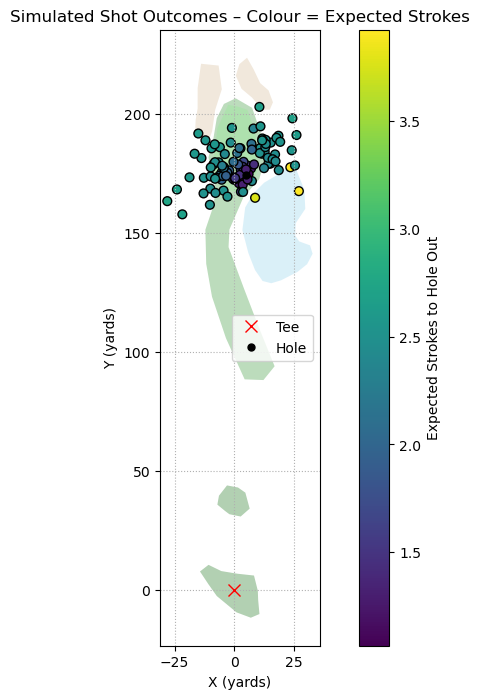

In [25]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Run simulation
results = simulate_and_evaluate(tee_point, hole, "Hybrid", aim_offset=-9, n_samples = 100)
evaluated_shots = results["evaluated_shots"]

# Extract data
xs = [r["landing_point"][0] for r in evaluated_shots]
ys = [r["landing_point"][1] for r in evaluated_shots]
strokes = [r["expected_strokes"] for r in evaluated_shots]

# Create a color map based on strokes
norm = Normalize(vmin=min(strokes), vmax=max(strokes))
cmap = cm.viridis

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Optional: draw hole geometry
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, fc=color, alpha=0.3)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)

# Plot shots with colour-coded expected strokes
sc = ax.scatter(xs, ys, c=strokes, cmap=cmap, norm=norm, s=40, edgecolor='k')

# Tee and hole
ax.plot(tee_point[0], tee_point[1], 'rx', label='Tee', markersize=8)
ax.plot(hole[0], hole[1], 'ko', label='Hole', markersize=5)

# Colour bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Expected Strokes to Hole Out")

ax.set_title("Simulated Shot Outcomes – Colour = Expected Strokes")
ax.set_xlabel("X (yards)")
ax.set_ylabel("Y (yards)")
ax.set_aspect('equal')
ax.legend()
plt.grid(True, linestyle=':')
plt.show()


# Finding the Optimal Combo

In [26]:
def simulate_all(starting_point, hole, clubs, aim_range=(-20, 20), aim_step=1, n_samples=20):
    start, stop = aim_range
    aim_points = range(start, stop + 1, aim_step) 

    club_results = {}

    for club in clubs:
        club_results[club] = []  # initialise list to store each aim's result

        for aim in aim_points:
            sim = simulate_and_evaluate(starting_point, hole, club, aim_offset=aim, n_samples=n_samples)
            club_results[club].append({
                "aim_offset": aim,
                "mean": sim["mean_expected_strokes"],
                "variance": sim["variance_expected_strokes"],
                "shots": sim["evaluated_shots"]
            })

    return club_results

# Finds the single best club/aimpoint combination with the lowest mean expected strokes.
def optimal_club_aimpoint_combination(club_results):
    best = None
    best_score = float('inf')
    
    for club, sims in club_results.items():
        for sim in sims:
            if sim["mean"] < best_score:
                best_score = sim["mean"]
                best = {"club": club, "aim_offset": sim["aim_offset"], "mean": sim["mean"], "variance": sim["variance"]}
    return best

# Averages all aimpoint combinations for each club and returns the club with the lowest average.
def optimal_club_ignoring_aim(club_results):
    summary = []
    for club, sims in club_results.items():
        means = [sim["mean"] for sim in sims if not np.isnan(sim["mean"])]
        avg_mean = np.mean(means) if means else np.nan
        summary.append((club, avg_mean))
    
    best = min(summary, key=lambda x: x[1])
    return {"club": best[0], "avg_mean": best[1]}

# For each club, returns the best aimpoint (with lowest mean expected strokes).
def optimal_aimpoint_per_club(club_results):
    results = {}
    for club, sims in club_results.items():
        best_aim = min(sims, key=lambda sim: sim["mean"] if not np.isnan(sim["mean"]) else float('inf'))
        results[club] = {"aim_offset": best_aim["aim_offset"], "mean": best_aim["mean"]}
    return results


In [27]:
clubs = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]

all_clubs_res = simulate_all(tee_point, hole, clubs=clubs, n_samples = 20)
back_pin = simulate_all(tee_point, (0, 200), clubs=clubs, n_samples = 20)

print(optimal_club_aimpoint_combination(all_clubs_res))
print(optimal_club_ignoring_aim(all_clubs_res))
print(optimal_aimpoint_per_club(all_clubs_res))

print("------------- Different Pin -------------------")

print(optimal_club_aimpoint_combination(back_pin))
print(optimal_club_ignoring_aim(back_pin))
print(optimal_aimpoint_per_club(back_pin))

{'club': 'Hybrid', 'aim_offset': -15, 'mean': 2.129400872669535, 'variance': 0.26488877964530116}
{'club': 'Hybrid', 'avg_mean': 2.538898664179769}
{'Driver': {'aim_offset': 2, 'mean': 2.9763599957925893}, '3-wood': {'aim_offset': 5, 'mean': 2.649619830462547}, '5-wood': {'aim_offset': 3, 'mean': 2.359766048653355}, 'Hybrid': {'aim_offset': -15, 'mean': 2.129400872669535}, '4 Iron': {'aim_offset': -2, 'mean': 2.278327405562646}, '5 Iron': {'aim_offset': -13, 'mean': 2.3179984180445565}, '6 Iron': {'aim_offset': -12, 'mean': 2.5652606735886643}, '7 Iron': {'aim_offset': -19, 'mean': 2.720718100377106}, '8 Iron': {'aim_offset': -17, 'mean': 2.8294190760849776}, '9 Iron': {'aim_offset': -12, 'mean': 2.9151267393113147}, 'PW': {'aim_offset': -1, 'mean': 3.002591953526095}, '50 deg': {'aim_offset': -7, 'mean': 2.9785786081260355}, '54 deg': {'aim_offset': 14, 'mean': 3.0114459848810347}, '60 deg': {'aim_offset': -6, 'mean': 3.050403862917806}}
------------- Different Pin -------------------

# Negative binomial for the odds of making a Putt

Once I have the expectation, I want not to model the number of strokes to hole out, but:
--> What's the probability that I hole out in exactly k strokes?

Answer this with a  probability distribution -> Negative Binomial Distribution
- Models the number of failures before a fixed number of successes (i.e. holing out)
- Each stroke is a Bernoulli trial -> where success is holing out
    + first sccess corresponds to holing out
    + the strokes leading up to that are failures
    + i.e. the total strokes = failures + 1

1.3 blurs important differences
- Two distributions can have the same mean, but one may have much higher chance of holing out and the other could be more spread out. 

Optimising for birdie chance -> care about the mass of te distribution on the low end

For a Negative Binomial Distribution:

$$X \sim NB(r,p), r = \text{num of successes til we stop expt}, p = \text{success prob in each expt}$$


# Generate fake data following a Negative Binomial

I want ot fit a GPR to the simulated data generated via: $X \sim NB(r, p(x,y))$
- $p(x,y)$ - one putt probability interpolated from Broadie Table PGA Tour Averages from 2003 - 2012
- $s(x,y)$ - expected number of strokes to hole out given by my parametric function (distance, green slope multipliers)

$$ \mathbb{E}(x) = s(x,y) = \frac{r}{p(x,y)} \rightarrow r = s(x,y) \cdot p(x,y)$$

In [28]:
# Distance (ft) and probabilities
distances = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60, 90])
one_putt_p = np.array([0.99, 0.96, 0.88, 0.77, 0.66, 0.58, 0.50, 0.45, 0.40,
                          0.23, 0.15, 0.07, 0.04, 0.03, 0.02, 0.01])
one_P_distance = interp1d(distances, one_putt_p, kind='linear', fill_value="extrapolate")

three_putt_p = np.array([0, 0.001, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.007, 0.013, 0.022, 0.05, 0.1, 0.17, 0.23, 0.41 ])
three_P_distance = interp1d(distances, three_putt_p, kind = 'linear', fill_value="extrapolate")

two_putt_p = []

for distance in distances:
    two_putt_p.append(1 - one_P_distance(distance) - three_P_distance(distance))

two_P_distance = interp1d(distances, two_putt_p, kind='linear', fill_value="extrapolate")

def compute_var(ball_loc, target):
    distance = np.linalg.norm(np.array(ball_loc) - np.array(target))
    p1 = one_P_distance(distance)
    p2 = two_P_distance(distance)
    p3 = three_P_distance(distance)

    mu_real = evaluate_on_green(ball_loc, target)

    mu_tab = p1 + 2*p2 + 3*p3
    var_tab = p1*(1-mu_tab)**2 + p2*(2-mu_tab)**2 + p3*(3-mu_tab)**2
    var_mix =  p1*(1-mu_real)**2 + p2*(2-mu_real)**2 + p3*(3-mu_real)**2

    return var_tab

def r_and_p(mu, var):
    p = 1/(var/mu + 1)    
    r = mu * p

    return r, p

def nb_params(ball_loc, target):
    mu = evaluate_on_green(ball_loc, target)
    var = compute_var(ball_loc, target) 
    return r_and_p(mu, var)

def sample_nbin(ball_loc, target, n_samples=47):
    r, p = nb_params(ball_loc, target)

    if r <= 0 or not (0 < p < 1):
        return np.full(n_samples, np.nan)
    
    samples = np.random.negative_binomial(n=r, p=p, size=n_samples)

    total_strokes = samples + r

    return total_strokes

So now:
$$Strokes \sim NB(r(x,y), p(x,y))$$

There are an average of 156 players at each pga tournament, so on any given day, we will be able to record the outcomes for 156 of these players. 

I'm going to sample 156 random points on the green. Evaluate a NB at each one of those points, to create a fake sample of a days worth of putts.

x=5.7, y=190.3, dist=16.3, p=0.209, s=2.253, r=0.471, simulated_strokes=1.000 
x=2.0, y=197.7, dist=23.9, p=0.119, s=2.482, r=0.294, simulated_strokes=1.000 
x=0.4, y=178.7, dist=6.5, p=0.618, s=1.942, r=1.200, simulated_strokes=1.000 
x=8.8, y=184.4, dist=11.1, p=0.362, s=1.893, r=0.685, simulated_strokes=1.000 
x=8.9, y=176.9, dist=4.9, p=0.783, s=1.425, r=1.116, simulated_strokes=2.000 
x=-5.3, y=194.1, dist=22.6, p=0.129, s=2.683, r=0.347, simulated_strokes=5.000 
x=8.1, y=189.6, dist=15.9, p=0.215, s=2.195, r=0.472, simulated_strokes=2.000 
x=3.6, y=187.1, dist=13.2, p=0.292, s=2.175, r=0.636, simulated_strokes=2.000 
x=-5.1, y=195.9, dist=24.1, p=0.117, s=2.679, r=0.313, simulated_strokes=2.000 
x=-5.9, y=184.7, dist=15.3, p=0.225, s=2.544, r=0.573, simulated_strokes=3.000 


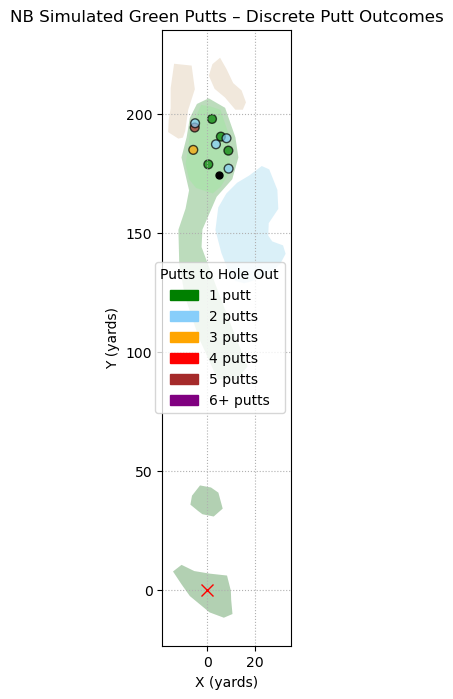

TypeError: evaluate_on_green() missing 2 required positional arguments: 'point' and 'target'

In [30]:
def simulate_one_putt_per_player(green_shape=green_shape, target = hole, n_players=156):
    samples = []

    for _ in range(n_players):
        ball = sample_point_on_green(green_shape)
        dist = np.linalg.norm(np.array(ball) - np.array(target))
        p = float(one_P_distance(dist))  # one-putt probability
        s = evaluate_on_green(ball, target)  # expected strokes
        r = s * p

        if r <= 0 or not (0 < p < 1):
            continue  # skip invalid configurations

        try:
            # Draw one sample from NB
            raw_stroke = np.random.negative_binomial(r, p) + 1
            stroke = min(int(np.round(raw_stroke)), 5)
            samples.append({
                "x": ball[0],
                "y": ball[1],
                "distance": dist,
                "p_one_putt": p,
                "expected_strokes": s,
                "r": r,
                "simulated_strokes": stroke
            })
        except ValueError:
            continue  # issues
        print(f"x={ball[0]:.1f}, y={ball[1]:.1f}, dist={dist:.1f}, p={p:.3f}, s={s:.3f}, r={r:.3f}, simulated_strokes={stroke:.3f} ")

    return pd.DataFrame(samples)



putt_color_map = {
    1: "green",
    2: "lightskyblue",
    3: "orange",
    4: "red",
    5: "brown"
}
default_color = "purple"

from matplotlib.patches import Patch

def plot_nb_putts(df_samples, hole_geom_df, tee_point, hole_point, stroke_col="simulated_strokes"):
    # Extract shot data
    xs = df_samples["x"].values
    ys = df_samples["y"].values
    strokes = df_samples[stroke_col].astype(int).values  # ensure integer strokes

    # Define discrete color map
    putt_color_map = {
        1: "green",
        2: "lightskyblue",
        3: "orange",
        4: "red",
        5: "brown"
    }
    default_color = "purple"
    colors = [putt_color_map.get(s, default_color) for s in strokes]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Draw hole geometry
    for _, row in hole_geom_df.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.3)

    # Plot sampled putts with assigned colours
    sc = ax.scatter(xs, ys, color=colors, s=40, edgecolor='k', alpha = .7)

    # Tee and hole markers
    ax.plot(tee_point[0], tee_point[1], 'rx', label='Tee', markersize=8)
    ax.plot(hole_point[0], hole_point[1], 'ko', label='Hole', markersize=5)

    # Custom legend
    legend_handles = [
        Patch(color="green", label="1 putt"),
        Patch(color="lightskyblue", label="2 putts"),
        Patch(color="orange", label="3 putts"),
        Patch(color="red", label="4 putts"),
        Patch(color="brown", label="5 putts"),
        Patch(color="purple", label="6+ putts")
    ]
    ax.legend(handles=legend_handles, title="Putts to Hole Out")

    # Formatting
    ax.set_title("NB Simulated Green Putts – Discrete Putt Outcomes")
    ax.set_xlabel("X (yards)")
    ax.set_ylabel("Y (yards)")
    ax.set_aspect('equal')
    plt.grid(True, linestyle=':')
    plt.show()

# df_tournament_putts is your NB-simulated dataframe from earlier
plot_nb_putts(
    df_samples= simulate_one_putt_per_player(n_players=10),
    hole_geom_df=hole_9,
    tee_point=tee_point,
    hole_point=hole
)

evaluate_on_green()

In [ ]:
evaluate_on_green((5.5,196.4), hole)

print(one_P_distance(22.4))
print(two_P_distance(22.4))
print(three_P_distance(22.4))

0.1308
0.8404799999999999
0.028719999999999996


# Discrete Inverse Transform

Instead, I will sample from discrete wanted values:

Say at a given distance 22.4 ft, the expectation given by my parametric model is 2.4. But then the probabilities of one, two and three putts respectively is:
$$p_1 = .13,\; p_2 = .84,\; p_3 = .03$$

I am going to shift some weight from 2 putts to 3 putts in order to have my probability estimated expectation be 2.4.
So something of the following sort:

$$ \mu = .13 + (1-a) \times 2(.84) + a \times 3(.03) = 2.4 $$

Then I am going to sample from a uniform distribution to get the discrete values.


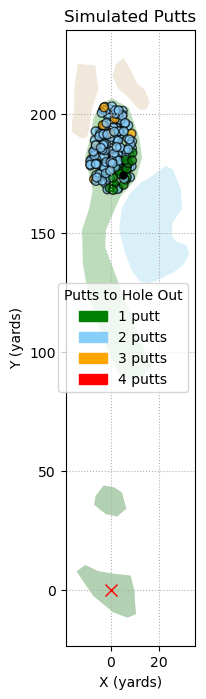

In [56]:
def from_2p_to_3p(expected, p1, p2, p3, ns = 1):

    # solving for the shift value from 2 to 3 putt
    empirical_mu = p1 + 2*p2 + 3*p3
    a = (expected - empirical_mu) / p2

    p1_adj = p1
    p2_adj = (1 - a) * p2
    p3_adj = p3 + a * p2

    cdf = np.cumsum([p1_adj, p2_adj, p3_adj])
    u = np.random.uniform(size=ns)

    # CDF for inverse transform
    cdf = np.cumsum([p1_adj, p2_adj, p3_adj])

    # Draw uniform samples and map to {1, 2, 3}
    u = np.random.uniform(size=ns)
    samples = np.select(
        [u < cdf[0], u < cdf[1]],
        [1, 2],
        default=3
    )
    return samples

def from_1p_2p_3p(expected, p1, p2, p3, a = .9, ns = 1):
    empirical_mu = p1 + 2 * p2 + 3 * p3
    diff = expected - empirical_mu

    p12_change = diff * a
    p23_change = diff * (1 - a)

    p1_adj = p1 - p12_change
    p2_adj = p2 + p12_change - p23_change
    p3_adj = p3 + p23_change

    total = p1_adj +   p2_adj + p3_adj

    new_empirical = p1_adj + 2*p2_adj + 3*p3_adj
    # Sample using inverse CDF
    cdf = np.cumsum([p1_adj, p2_adj, p3_adj])
    u = np.random.uniform(size=ns)
    samples = np.select(
        [u < cdf[0], u < cdf[1]],
        [1, 2],
        default=3
    )
    return samples


def simulate_one_putt_per_player(green_shape=green_shape, target = hole, n_players=156):
    samples = []

    for _ in range(n_players):
        ball = sample_point_on_green(green_shape)
        dist = np.linalg.norm(np.array(ball) - np.array(target))
        s = evaluate_on_green(ball, target)  # expected strokes

    for _ in range(n_players):
        ball = sample_point_on_green(green_shape)
        dist = np.linalg.norm(np.array(ball) - np.array(target))
        s = evaluate_on_green(ball, target)

        p1 = one_P_distance(dist)
        p2 = two_P_distance(dist)
        p3 = three_P_distance(dist)

        try:
            #stroke = int(from_2p_to_3p(s, p1, p2, p3, ns=1)[0])
            stroke = int(from_1p_2p_3p(s, p1, p2, p3, a = .92, ns = 1 )[0])
            #from_1p_2p_3p(expected, p1, p2, p3, a = .8, ns = 1)
            samples.append({
                "x": ball[0],
                "y": ball[1],
                "distance": dist,
                "expected_strokes": s,
                "simulated_strokes": stroke
            })
        except Exception as e:
            print("Error:", e)
            continue

    return pd.DataFrame(samples)


putt_color_map = {
    1: "green",
    2: "lightskyblue",
    3: "orange",
    4: "red",
    5: "brown"
}
default_color = "purple"

from matplotlib.patches import Patch

def plot_putts(df_samples, hole_geom_df, tee_point, hole_point, stroke_col="simulated_strokes"):
    # Extract shot data
    xs = df_samples["x"].values
    ys = df_samples["y"].values
    strokes = df_samples[stroke_col].astype(int).values  # ensure integer strokes

    # Define discrete color map
    putt_color_map = {
        1: "green",
        2: "lightskyblue",
        3: "orange",
        4: "red",
        5: "brown"
    }
    default_color = "purple"
    colors = [putt_color_map.get(s, default_color) for s in strokes]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Draw hole geometry
    for _, row in hole_geom_df.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.3)

    # Plot sampled putts with assigned colours
    sc = ax.scatter(xs, ys, color=colors, s=40, edgecolor='k', alpha = .7)

    # Tee and hole markers
    ax.plot(tee_point[0], tee_point[1], 'rx', label='Tee', markersize=8)
    ax.plot(hole_point[0], hole_point[1], 'ko', label='Hole', markersize=5)

    # Custom legend
    legend_handles = [
        Patch(color="green", label="1 putt"),
        Patch(color="lightskyblue", label="2 putts"),
        Patch(color="orange", label="3 putts"),
        Patch(color="red", label="4 putts"),
    ]
    ax.legend(handles=legend_handles, title="Putts to Hole Out")

    # Formatting 
    ax.set_title("Simulated Putts")
    ax.set_xlabel("X (yards)")
    ax.set_ylabel("Y (yards)")
    ax.set_aspect('equal')
    plt.grid(True, linestyle=':')
    plt.show()

    return df_samples


# df_tournament_putts is your NB-simulated dataframe from earlier
gpr_green_dataset = plot_putts(
    df_samples= simulate_one_putt_per_player(n_players=156),
    hole_geom_df=hole_9,
    tee_point=tee_point,
    hole_point=hole )

gpr_green_dataset.to_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 2/Green simulation/results/gpr_green_dataset2.csv")


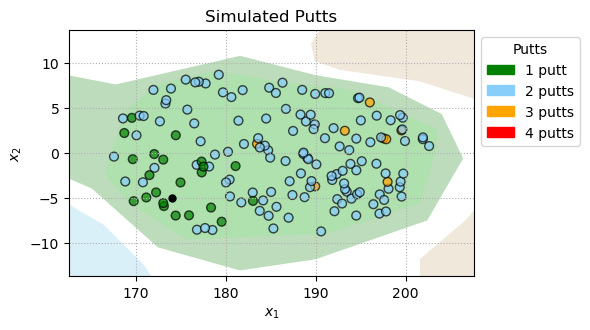

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from shapely import wkt, affinity
from matplotlib.patches import Patch

def plot_putts_rotated(df_samples, hole_geom_df, tee_point, hole_point, 
                       stroke_col="simulated_strokes", rotation_angle=90, zoom_buffer=5):
    """
    Plots the putts rotated by a specific angle and zoomed in on the green.
    
    Parameters:
    - rotation_angle: Degrees to rotate (counter-clockwise).
    - zoom_buffer: Yards of extra space around the putts to show.
    """
    
    # 1. Prepare Rotation Logic
    # We rotate everything around (0,0) to keep relative positions consistent.
    # The view limits will handle the "centering" later.
    origin = (0, 0)
    theta = np.radians(rotation_angle)
    c, s = np.cos(theta), np.sin(theta)
    rotation_matrix = np.array(((c, -s), (s, c)))

    # 2. Extract and Rotate Shot Data (Vectorized for speed)
    points = np.vstack([df_samples["x"].values, df_samples["y"].values])
    rotated_points = rotation_matrix @ points
    xs_rot = rotated_points[0, :]
    ys_rot = rotated_points[1, :]
    
    strokes = df_samples[stroke_col].astype(int).values

    # 3. Rotate Tee and Hole Markers
    tee_rot = rotation_matrix @ np.array(tee_point)
    hole_rot = rotation_matrix @ np.array(hole_point)

    # 4. Define Color Map
    putt_color_map = {
        1: "green",
        2: "lightskyblue",
        3: "orange",
        4: "red",
        5: "brown"
    }
    default_color = "purple"
    colors = [putt_color_map.get(s, default_color) for s in strokes]

    # 5. Plotting
    # Smaller figsize since we are zooming in on just the green
    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw Rotated Hole Geometry
    # We define the view limits based on the putts, so we only need to plot
    # geometries that might be visible, but plotting all is usually fine if not huge.
    for _, row in hole_geom_df.iterrows():
        geom = wkt.loads(row["WKT"])
        # Rotate the shapely geometry
        geom_rot = affinity.rotate(geom, rotation_angle, origin=origin)
        
        color = lie_colors.get(row["lie"], "lightgrey") # Assuming lie_colors exists in scope
        
        if geom_rot.geom_type == "Polygon":
            x, y = geom_rot.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)
        elif geom_rot.geom_type == "MultiPolygon":
            for poly in geom_rot.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.3)

    # Plot Rotated Scatter Points
    ax.scatter(xs_rot, ys_rot, color=colors, s=40, edgecolor='k', alpha=0.7)

    # Plot Rotated Markers
    ax.plot(tee_rot[0], tee_rot[1], 'rx', label='Tee', markersize=8)
    ax.plot(hole_rot[0], hole_rot[1], 'ko', label='Hole', markersize=5)

    # 6. Zoom in on the Green
    # We use the bounds of the simulated putts to determine the view
    min_x, max_x = xs_rot.min(), xs_rot.max()
    min_y, max_y = ys_rot.min(), ys_rot.max()

    ax.set_xlim(min_x - zoom_buffer, max_x + zoom_buffer)
    ax.set_ylim(min_y - zoom_buffer, max_y + zoom_buffer)

    # Legend
    legend_handles = [
        Patch(color="green", label="1 putt"),
        Patch(color="lightskyblue", label="2 putts"),
        Patch(color="orange", label="3 putts"),
        Patch(color="red", label="4 putts"),
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1), title="Putts")

    # Formatting
    ax.set_title(f"Simulated Putts")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect('equal')
    plt.grid(True, linestyle=':')
    plt.tight_layout() # Helps with the legend outside the box
    plt.show()

    return df_samples

# Usage Example:
# gpr_green_dataset = plot_putts_rotated(
#     df_samples=simulate_one_putt_per_player(n_players=156),
#     hole_geom_df=hole_9,
#     tee_point=tee_point,
#     hole_point=hole,
#     rotation_angle=90,  # Rotates 90 degrees counter-clockwise
#     zoom_buffer=3       # Only shows 3 yards around the furthest balls
# )

gpr_green_dataset = plot_putts_rotated(
    df_samples= simulate_one_putt_per_player(n_players=156),
    hole_geom_df=hole_9,
    tee_point=tee_point,
    hole_point=hole,
    stroke_col="simulated_strokes", 
    rotation_angle=-90, 
    zoom_buffer=5
    )

# Generating GPR from this data -> scikit learn

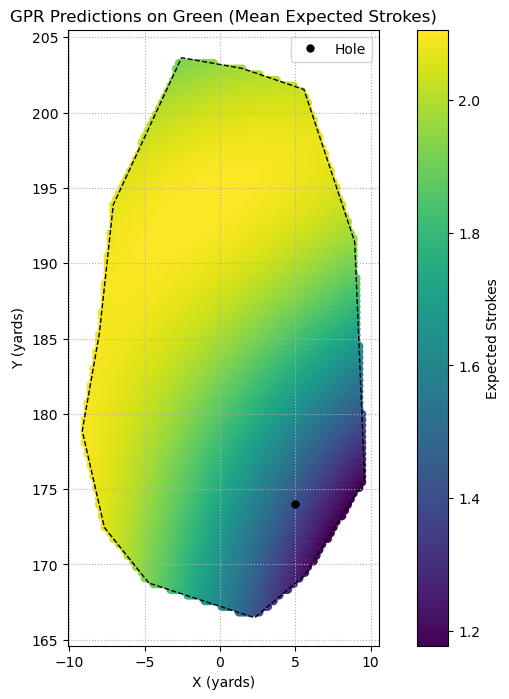

In [52]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

X = gpr_green_dataset[["x", "y"]].values  
y = gpr_green_dataset["simulated_strokes"].values

kernel = RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)


# normalising noise with the white kernel so letting alpha be 0
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0)

gpr.fit(X,y)
# Sample green polygon
green_bounds = green_shape.bounds  # (minx, miny, maxx, maxy)

# Create a fine grid
xx, yy = np.meshgrid(
    np.linspace(green_bounds[0], green_bounds[2], 100),
    np.linspace(green_bounds[1], green_bounds[3], 100)
)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# Only keep grid points within the green polygon
inside_mask = np.array([green_shape.contains(Point(x, y)) for x, y in grid_points])
X_test = grid_points[inside_mask]

# Predict expected strokes and uncertainty
mean_pred, std_pred = gpr.predict(X_test, return_std=True)

# Plotting setup
plt.figure(figsize=(10, 8))
sc = plt.scatter(X_test[:, 0], X_test[:, 1], c=mean_pred, cmap="viridis", s=30)
plt.colorbar(sc, label="Expected Strokes")
plt.title("GPR Predictions on Green (Mean Expected Strokes)")
plt.xlabel("X (yards)")
plt.ylabel("Y (yards)")
plt.gca().set_aspect('equal')

# Draw green outline
# Handle MultiPolygon or Polygon
if green_shape.geom_type == "Polygon":
    x_green, y_green = green_shape.exterior.xy
    plt.plot(x_green, y_green, 'k--', lw=1)
elif green_shape.geom_type == "MultiPolygon":
    for poly in green_shape.geoms:
        x_green, y_green = poly.exterior.xy
        plt.plot(x_green, y_green, 'k--', lw=1)


# Overlay hole
plt.plot(hole[0], hole[1], 'ko', label='Hole', markersize=5)

plt.grid(True, linestyle=':')
plt.legend()
plt.show()


# Generating GPR from this Data -> GPyTorch

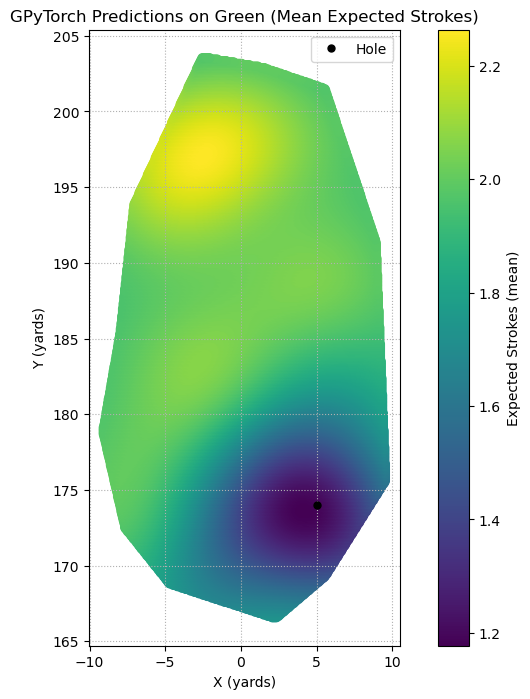

In [59]:
import torch
import gpytorch

# training data
X_train = torch.tensor(gpr_green_dataset[["x", "y"]].values, dtype=torch.float32)
y_train = torch.tensor(gpr_green_dataset["simulated_strokes"].values, dtype=torch.float32)

# GP model
class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModel(X_train, y_train, likelihood)

# training model
model.train()
likelihood.train()

#lr is the rate of gradient ascent
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 100
for i in range(training_iter):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()

# Now evaluate the model
model.eval()
likelihood.eval()

#plot
minx, miny, maxx, maxy = green_shape.bounds
grid_x, grid_y = np.linspace(minx, maxx, 400), np.linspace(miny, maxy, 400)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
inside_mask = np.array([green_shape.contains(Point(x, y)) for x, y in grid_points])
X_test_np = grid_points[inside_mask]
X_test = torch.tensor(X_test_np, dtype=torch.float32)

# Predict in batches to avoid memory issues
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(model(X_test))
    mean = preds.mean.numpy()
    stddev = preds.stddev.numpy()

# Plot results
plt.figure(figsize=(10, 8))
sc = plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=mean, cmap='viridis', s=30)
plt.colorbar(sc, label="Expected Strokes (mean)")
plt.title("GPyTorch Predictions on Green (Mean Expected Strokes)")
plt.xlabel("X (yards)")
plt.ylabel("Y (yards)")
plt.gca().set_aspect('equal')

# # Outline green
# if green_shape.geom_type == "Polygon":
#     x_green, y_green = green_shape.exterior.xy
#     plt.plot(x_green, y_green, 'k--', lw=1)
# elif green_shape.geom_type == "MultiPolygon":
#     for poly in green_shape.geoms:
#         x_green, y_green = poly.exterior.xy
#         plt.plot(x_green, y_green, 'k--', lw=1)

# Hole marker
plt.plot(hole[0], hole[1], 'ko', label='Hole', markersize=5)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()


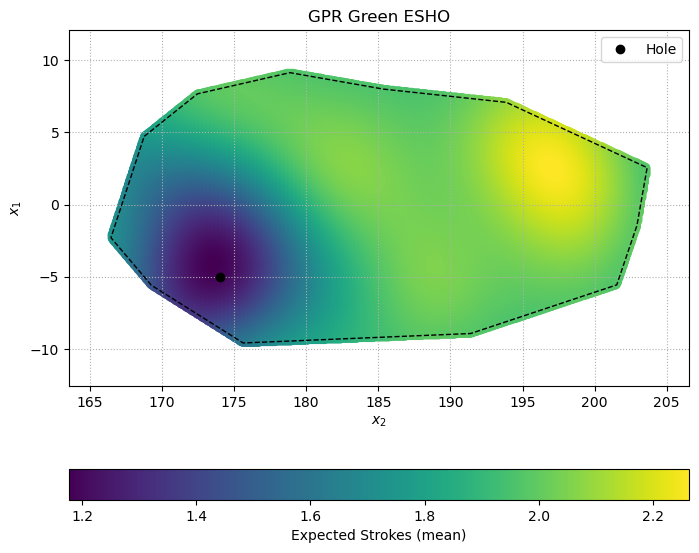

In [66]:
# ROTATED LOGIC GEMINI
# 1. Evaluate Model (In Original Coordinate Space)
model.eval()
likelihood.eval()

# Generate grid based on ORIGINAL bounds
minx, miny, maxx, maxy = green_shape.bounds
grid_x, grid_y = np.linspace(minx, maxx, 400), np.linspace(miny, maxy, 400)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# Filter points inside the green
inside_mask = np.array([green_shape.contains(Point(x, y)) for x, y in grid_points])
X_test_np = grid_points[inside_mask]
X_test = torch.tensor(X_test_np, dtype=torch.float32)

# Predict
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(model(X_test))
    mean = preds.mean.numpy()

# 2. Apply Rotation Logic (Just for Visualization)
rotation_angle = -90
theta = np.radians(rotation_angle)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array(((c, -s), (s, c)))

# Rotate the Grid Points (Transpose -> Multiply -> Transpose back)
X_test_rotated = (rotation_matrix @ X_test_np.T).T 

# Rotate the Hole
hole_rotated = rotation_matrix @ np.array(hole)

# Rotate the Green Outline (using Shapely)
green_rotated = affinity.rotate(green_shape, rotation_angle, origin=(0, 0))

# 3. Plot
fig, ax = plt.subplots(figsize=(8, 9)) # Slightly taller to accommodate bottom legend

# Scatter plot using rotated coordinates
sc = ax.scatter(X_test_rotated[:, 0], X_test_rotated[:, 1], c=mean, cmap='viridis', s=30)

# Plot Rotated Outline
if green_rotated.geom_type == "Polygon":
    x_g, y_g = green_rotated.exterior.xy
    ax.plot(x_g, y_g, 'k--', lw=1)
elif green_rotated.geom_type == "MultiPolygon":
    for poly in green_rotated.geoms:
        x_g, y_g = poly.exterior.xy
        ax.plot(x_g, y_g, 'k--', lw=1)

# Plot Rotated Hole
ax.plot(hole_rotated[0], hole_rotated[1], 'ko', label='Hole', markersize=6)

# Auto-zoom on the green
min_x_rot, max_x_rot = X_test_rotated[:, 0].min(), X_test_rotated[:, 0].max()
min_y_rot, max_y_rot = X_test_rotated[:, 1].min(), X_test_rotated[:, 1].max()
buffer = 3 
ax.set_xlim(min_x_rot - buffer, max_x_rot + buffer)
ax.set_ylim(min_y_rot - buffer, max_y_rot + buffer)

# Formatting
plt.title(f"GPR Green ESHO")
plt.xlabel("$x_2$")
plt.ylabel("$x_1$")
ax.set_aspect('equal')
plt.grid(True, linestyle=':')

# --- MOVED LEGENDS ---

# 1. The "Hole" Marker Legend
ax.legend(loc='best') 

# 2. The Colorbar (Rotated Horizontal & Moved to Bottom)
cbar = plt.colorbar(sc, orientation='horizontal', pad=0.12)
cbar.set_label("Expected Strokes (mean)")

plt.show()

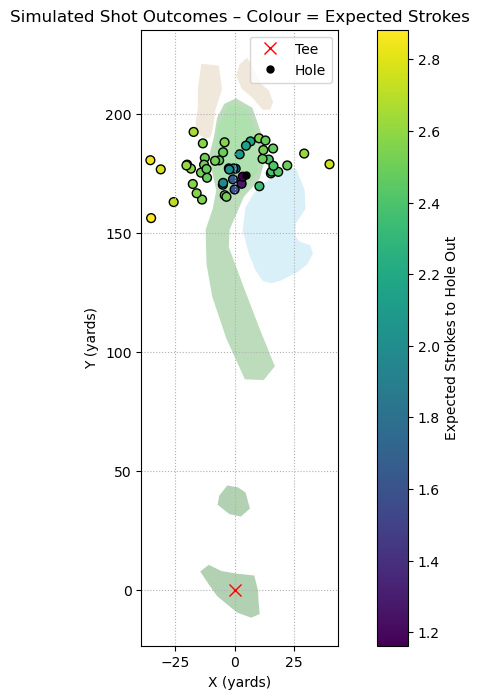

In [434]:
def evaluate_on_green2(point, model, likelihood):    
    model.eval()
    likelihood.eval()

    test_x = torch.tensor([[point[0], point[1]]], dtype=torch.float)

    with torch.no_grad():
        pred = likelihood(model(test_x))
        mean = pred.mean.item()
        std = pred.stddev.item()

    return mean, std

def evaluate_shot2(point, starting_point, target):
    lie = get_lie_category(point)

    if lie == "green":
        return evaluate_on_green2(point, model, likelihood)[0]
    elif lie == "fairway":
        return evaluate_broadie(point, target, "fairway")
    elif lie == "rough":
        return evaluate_broadie(point, target, "rough")
    elif lie == "bunker":
        return evaluate_broadie(point, target, "sand")
    elif lie == "water":
        return evaluate_water_hazard(point, starting_point, target)
    else:
        return evaluate_broadie(point, target, "rough")

def simulate_and_evaluate2(starting_point, target, club, aim_offset=0, n_samples=20):
    mu, cov = get_club_distribution(club)
    raw_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

    # Rotation setup
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_offset / total_distance)
    angle_deg = np.degrees(angle_rad)

    evaluated = []
    for shot in raw_samples:
        x_rot, y_rot = rotation_translator(shot[0], shot[1], angle_deg, starting_point, target)
        es = evaluate_shot2((x_rot, y_rot), starting_point, target)
        evaluated.append({
            "original_shot": (shot[0], shot[1]),
            "landing_point": (x_rot, y_rot),
            "expected_strokes": es
        })
        
   # Compute mean and variance of non-NaN strokes
    all_strokes = [d["expected_strokes"] for d in evaluated if not np.isnan(d["expected_strokes"])]
    mean_es = np.mean(all_strokes) if all_strokes else np.nan
    var_es = np.var(all_strokes) if all_strokes else np.nan

    return {
        "evaluated_shots": evaluated,
        "mean_expected_strokes": mean_es,
        "variance_expected_strokes": var_es
    }

from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Run simulation
results = simulate_and_evaluate(tee_point, hole, "4 Iron", aim_offset=-9, n_samples = 50)
evaluated_shots = results["evaluated_shots"]

# Extract data
xs = [r["landing_point"][0] for r in evaluated_shots]
ys = [r["landing_point"][1] for r in evaluated_shots]
strokes = [r["expected_strokes"] for r in evaluated_shots]

# Create a color map based on strokes
norm = Normalize(vmin=min(strokes), vmax=max(strokes))
cmap = cm.viridis

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Optional: draw hole geometry
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, fc=color, alpha=0.3)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)

# Plot shots with colour-coded expected strokes
sc = ax.scatter(xs, ys, c=strokes, cmap=cmap, norm=norm, s=40, edgecolor='k')

# Tee and hole
ax.plot(tee_point[0], tee_point[1], 'rx', label='Tee', markersize=8)
ax.plot(hole[0], hole[1], 'ko', label='Hole', markersize=5)

# Colour bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Expected Strokes to Hole Out")

ax.set_title("Simulated Shot Outcomes – Colour = Expected Strokes")
ax.set_xlabel("X (yards)")
ax.set_ylabel("Y (yards)")
ax.set_aspect('equal')
ax.legend()
plt.grid(True, linestyle=':')
plt.show()

In [439]:
def simulate_all2(starting_point, hole, clubs, aim_range=(-20, 20), aim_step=1, n_samples=20):
    start, stop = aim_range
    aim_points = range(start, stop + 1, aim_step)

    club_results = {}

    for club in clubs:
        club_results[club] = []  # Start a fresh list for this club

        for aim in aim_points:
            sim = simulate_and_evaluate2(
                starting_point=starting_point,
                target=hole,
                club=club,
                aim_offset=aim,
                n_samples=n_samples
            )

            club_results[club].append({
                "aim_offset": aim,
                "mean": sim["mean_expected_strokes"],
                "variance": sim["variance_expected_strokes"],
                "shots": sim["evaluated_shots"]
            })

    return club_results

# Finds the single best club/aimpoint combination with the lowest mean expected strokes.
def optimal_club_aimpoint_combination(club_results):
    best = None
    best_score = float('inf')
    
    for club, sims in club_results.items():
        for sim in sims:
            if sim["mean"] < best_score:
                best_score = sim["mean"]
                best = {"club": club, "aim_offset": sim["aim_offset"], "mean": sim["mean"], "variance": sim["variance"]}
    return best

# Averages all aimpoint combinations for each club and returns the club with the lowest average.
def optimal_club_ignoring_aim(club_results):
    summary = []
    for club, sims in club_results.items():
        means = [sim["mean"] for sim in sims if not np.isnan(sim["mean"])]
        avg_mean = np.mean(means) if means else np.nan
        summary.append((club, avg_mean))
    
    best = min(summary, key=lambda x: x[1])
    return {"club": best[0], "avg_mean": best[1]}

# For each club, returns the best aimpoint (with lowest mean expected strokes).
def optimal_aimpoint_per_club(club_results):
    results = {}
    for club, sims in club_results.items():
        best_aim = min(sims, key=lambda sim: sim["mean"] if not np.isnan(sim["mean"]) else float('inf'))
        results[club] = {"aim_offset": best_aim["aim_offset"], "mean": best_aim["mean"]}
    return results

clubs = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]

all_clubs_res = simulate_all(tee_point, hole, clubs=clubs, n_samples = 1000)

print(optimal_club_aimpoint_combination(all_clubs_res))
print(optimal_club_ignoring_aim(all_clubs_res))
print(optimal_aimpoint_per_club(all_clubs_res))


{'club': 'Hybrid', 'aim_offset': -8, 'mean': 2.2841276215950175, 'variance': 0.2656194531969364}
{'club': '4 Iron', 'avg_mean': 2.5525923442488936}
{'Driver': {'aim_offset': 0, 'mean': 3.010249008779595}, '3-wood': {'aim_offset': -3, 'mean': 2.6745843213009004}, '5-wood': {'aim_offset': 1, 'mean': 2.4990793663614648}, 'Hybrid': {'aim_offset': -8, 'mean': 2.2841276215950175}, '4 Iron': {'aim_offset': -7, 'mean': 2.37748003487795}, '5 Iron': {'aim_offset': -19, 'mean': 2.484600602149344}, '6 Iron': {'aim_offset': -20, 'mean': 2.71076102922158}, '7 Iron': {'aim_offset': -19, 'mean': 2.8850039094436317}, '8 Iron': {'aim_offset': -20, 'mean': 2.911824234710391}, '9 Iron': {'aim_offset': -19, 'mean': 2.966286753207465}, 'PW': {'aim_offset': -4, 'mean': 3.026100352234449}, '50 deg': {'aim_offset': -7, 'mean': 3.0144759816624402}, '54 deg': {'aim_offset': 2, 'mean': 3.0525408067451454}, '60 deg': {'aim_offset': 19, 'mean': 3.0655737609758953}}
